# **netflix_data anaysis**

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data set
df = pd.read_csv('/content/netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4589,s4590,Movie,My Little Pony Equestria Girls: Forgotten Frie...,Ishi Rudell,"Ashleigh Ball, Andrea Libman, Rebecca Shoichet...",United States,"October 1, 2018",2018,TV-Y,44 min,Children & Family Movies,School yearbook editor Sunset Shimmer has sudd...
6323,s6324,TV Show,Black Heart,NaN,"Barış Kılıç, Tuvana Türkay, Serhat Tutumluer, ...",Turkey,"October 12, 2018",2014,TV-14,1 Season,"Crime TV Shows, International TV Shows, TV Dramas",Blaming a crooked media mogul for the death of...
5175,s5176,TV Show,Lady Dynamite,NaN,"Maria Bamford, Fred Melamed, Mary Kay Place, E...",United States,"November 10, 2017",2017,TV-MA,2 Seasons,TV Comedies,Comedian Maria Bamford stars in a series inspi...
1614,s1615,TV Show,Gormiti,NaN,"Dermot Arrigan, Jenny Beacraft, Stephanie Figu...","Spain, Italy","December 1, 2020",2018,TV-Y,1 Season,Kids' TV,Four friends become guardians of the island Go...
1582,s1583,Movie,Triple 9,John Hillcoat,"Casey Affleck, Chiwetel Ejiofor, Anthony Macki...",United States,"December 8, 2020",2016,R,115 min,"Dramas, Thrillers",A group of dirty Atlanta cops blackmailed by t...


In [4]:
df.shape#before shape of data

(8807, 12)

In [8]:
df.describe()#how numerical column looks like

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.info()#how different columns looks like

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.isnull().sum()#before removing null valuess

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [16]:
df = df.drop('director' , axis=1)# i choose to drop director column as 30% data points were nan value

In [18]:
df.dropna(inplace=True)

In [19]:
df.isnull().sum()#after removing all null values

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.shape #after cleaning

(7290, 11)

In [23]:
df.columns

Index(['show_id', 'type', 'title', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [35]:
df.sample(3)

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description
4775,s4776,Movie,Romina,"Francisca Lozano, Oliver Nava, Arantza Ruiz, C...",Mexico,"July 13, 2018",2018,TV-MA,75 min,"Horror Movies, Independent Movies, Internation...",A shocking assault inspires horrific violence ...
2186,s2187,Movie,Raat Akeli Hai,"Nawazuddin Siddiqui, Radhika Apte, Khalid Tyab...",India,"July 31, 2020",2020,TV-MA,150 min,"Dramas, International Movies, Thrillers","When a newly married landlord is murdered, a m..."
8780,s8781,TV Show,Yo-Kai Watch,"Johnny Yong Bosch, J.W. Terry, Alicyn Packard,...",United States,"April 1, 2016",2015,TV-Y7,1 Season,"Anime Series, Kids' TV",Nate frees a mythical being trapped in a magic...


In [26]:
#lets change all the columns name and more meaningful
df.columns = (df.columns.str.lower().str.replace(' ','_' ,regex=False).str.lower())

In [39]:
#lets add some new columns for more meanning
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['released_month'] = df['date_added'].dt.month_name()

In [40]:
#change the index to be with show_id
df.set_index('show_id',inplace=True)

In [55]:
df.columns

Index(['type', 'title', 'cast', 'country', 'date_added', 'release_year',
       'rating', 'duration', 'listed_in', 'description', 'released_month'],
      dtype='object')

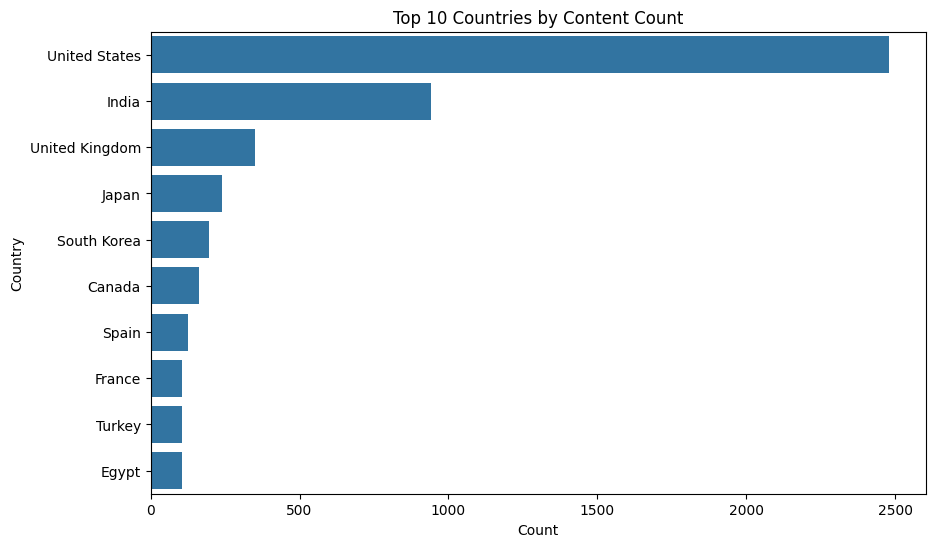

In [53]:
#lets do visulaisation
# which countery is having most content
plt.figure(figsize=(10,6))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [80]:
count_by_month = df['released_month'].value_counts()

/tmp/ipykernel_6862/2245964956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_by_month.values , y = count_by_month.index, palette='viridis')


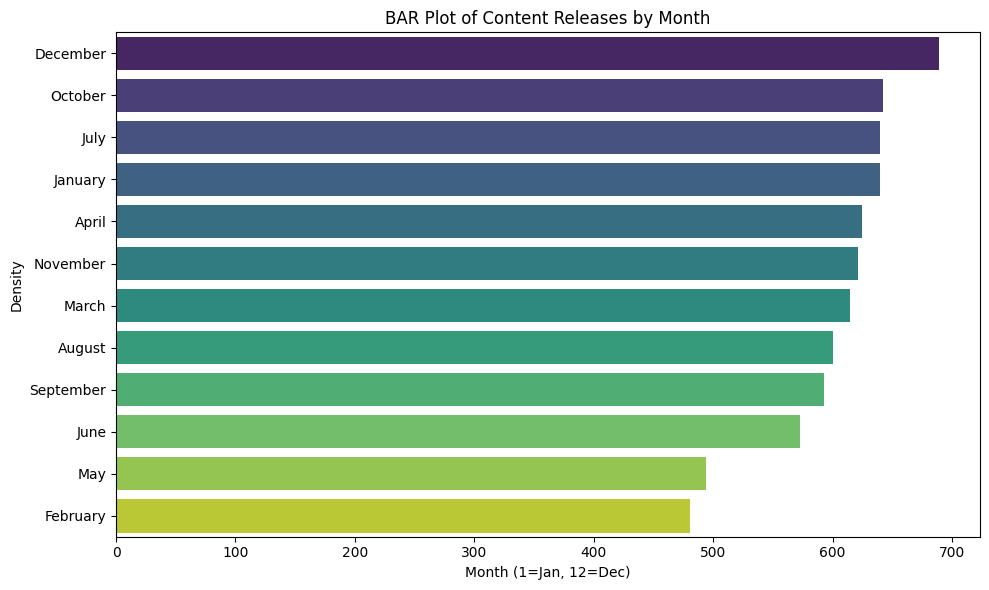

In [85]:
# Create the BAR
# which month is having most content

plt.figure(figsize=(10,6))
sns.barplot(x=count_by_month.values , y = count_by_month.index, palette='viridis')
plt.title('BAR Plot of Content Releases by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6862/2652125406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


Text(0.5, 1.0, 'Distribution of Content Types')

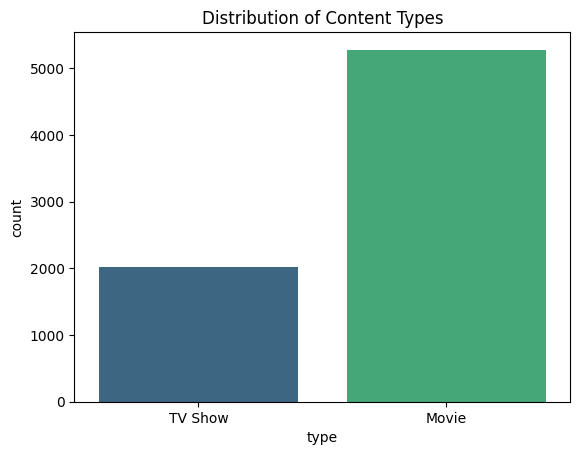

In [92]:
#what is the distribution of type
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Distribution of Content Types')

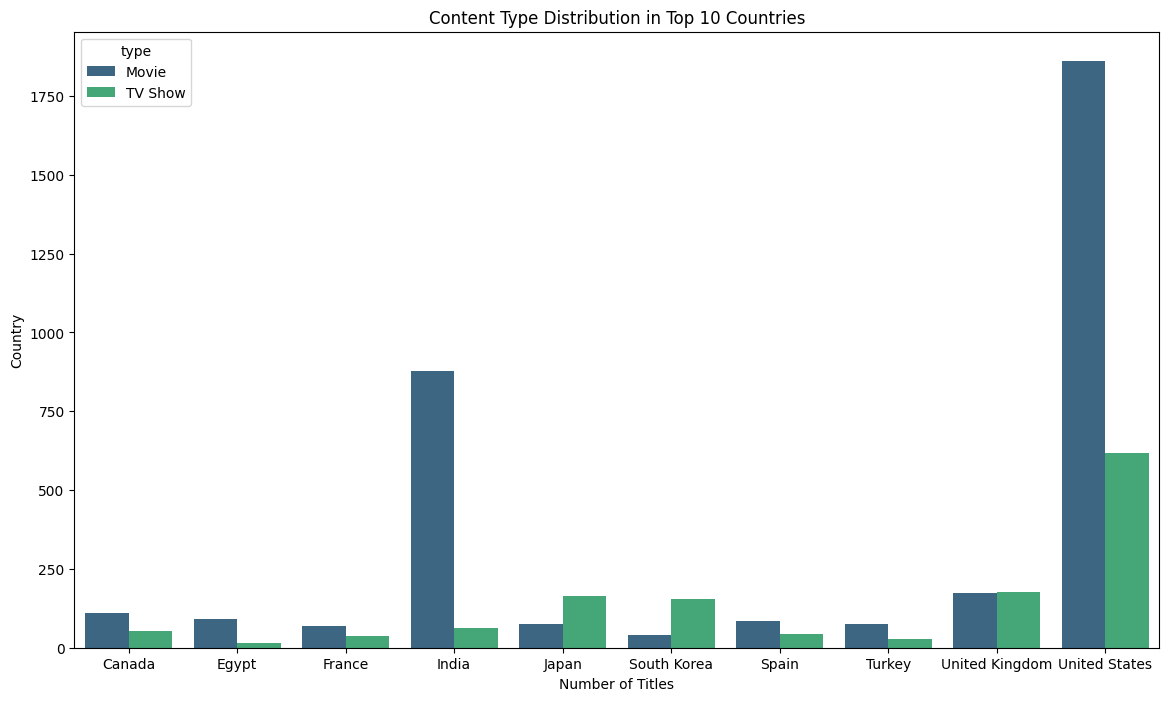

In [95]:
# which country is having most content by their types
plt.figure(figsize=(14, 8))

# Get the top 10 countries based on overall content count
top_10_countries = df['country'].value_counts().head(10).index

# Filter the DataFrame to include only these top 10 countries
df_top_countries = df[df['country'].isin(top_10_countries)]

# Calculate counts of 'type' for each of the top countries
country_type_counts = df_top_countries.groupby(['country', 'type']).size().reset_index(name='count')

# Create the bar plot with hue
sns.barplot(data=country_type_counts, y='count', x='country', hue='type', palette='viridis')
plt.title('Content Type Distribution in Top 10 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

In [93]:
df.sample(5)

,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description,released_month
show_id,,,,,,,,,,,
s8563,Movie,The Women's Balcony,"Evelin Hagoel, Igal Naor, Orna Banay, Einat Sa...",Israel,2017-12-19,2016,TV-PG,100 min,"Comedies, Dramas, Faith & Spirituality",A conservative rabbi steps in to lead a congre...,December
s6033,Movie,A Dangerous Woman,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,2018-04-01,1993,R,101 min,"Dramas, Romantic Movies",At the center of this engrossing melodrama is ...,April
s2145,TV Show,GAME ON: A Comedy Crossover Event,"Loretta Devine, Tia Mowry-Hardrict, Anthony Al...",United States,2020-08-10,2020,TV-G,1 Season,"Kids' TV, TV Comedies",Worlds collide in this special event featuring...,August
s7603,Movie,NOVA: Chinese Chariot Revealed,Eric Meyers,United States,2019-07-01,2017,TV-PG,54 min,Documentaries,The chariot dominated Chinese warfare for mill...,July
s3138,TV Show,Girls und Panzer,"Mai Fuchigami, Ai Kayano, Mami Ozaki, Ikumi Na...",Japan,2019-12-15,2012,TV-PG,1 Season,"Anime Series, International TV Shows",Miho Nishizumi tries to escape her family's tr...,December


<Figure size 1500x800 with 0 Axes>

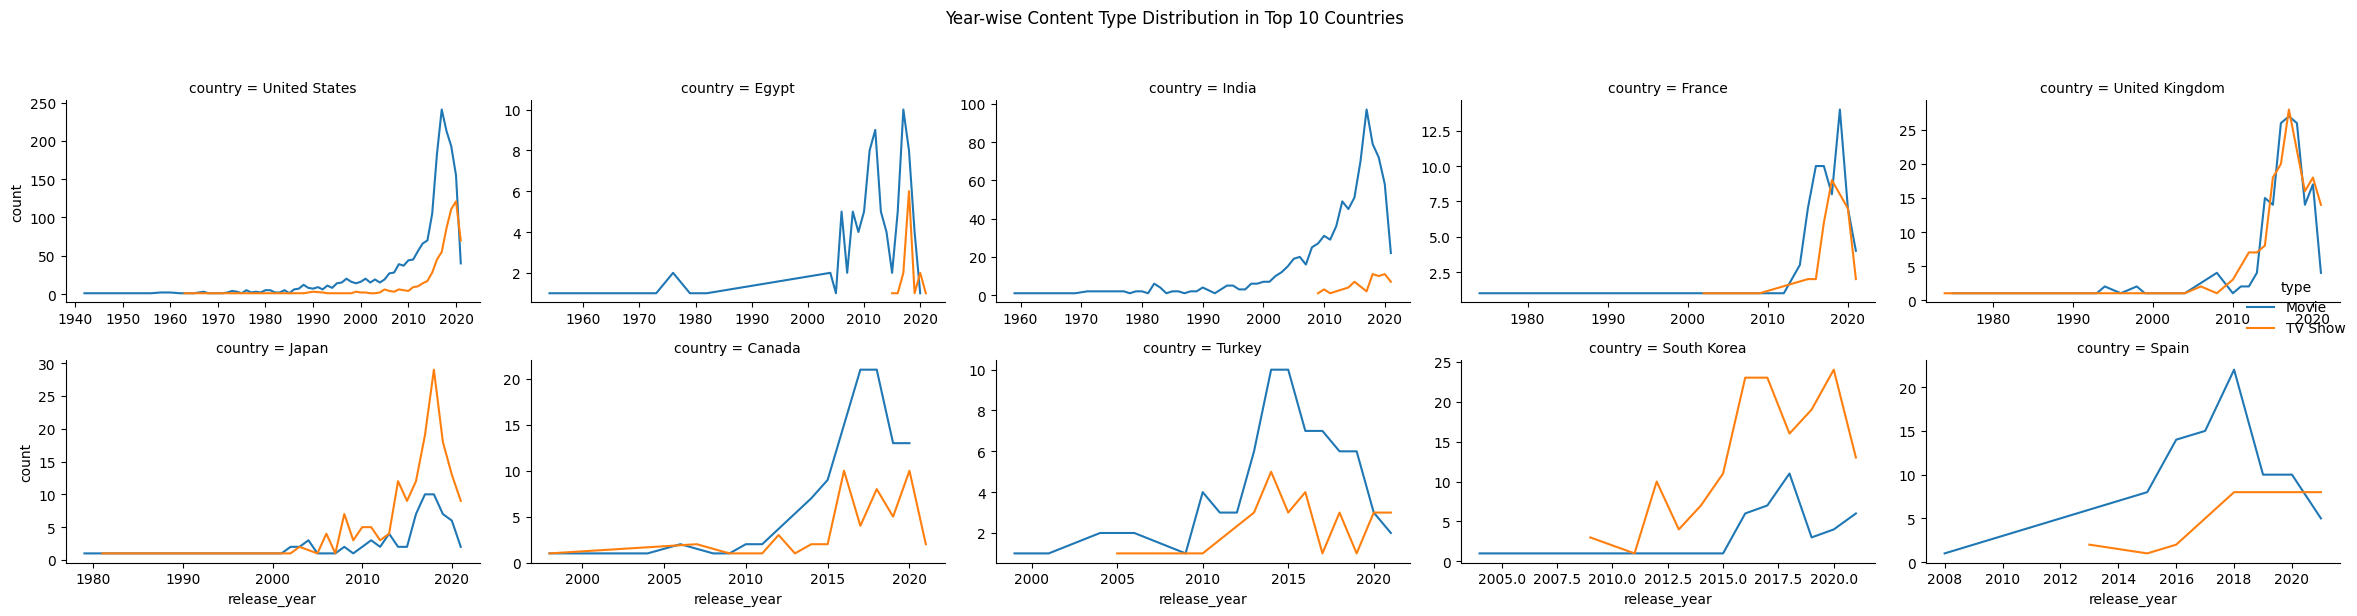

In [94]:
# year wise distribution of type of top 10 countries

# Ensure df_top_countries is available, or recreate it if the notebook state was reset
# Get the top 10 countries based on overall content count (assuming 'df' is available and processed)
top_10_countries = df['country'].value_counts().head(10).index
df_top_countries = df[df['country'].isin(top_10_countries)]

# Calculate counts of 'type' for each year and country
year_country_type_counts = df_top_countries.groupby(['release_year', 'country', 'type']).size().reset_index(name='count')

plt.figure(figsize=(15, 8))

# Create a line plot for each country, showing movie and TV show counts over years
sns.relplot(
    data=year_country_type_counts,
    x='release_year',
    y='count',
    hue='type',
    col='country',
    col_wrap=5, # Adjust based on number of countries
    kind='line',
    height=3,
    aspect=1.5,
    facet_kws={'sharex': False, 'sharey': False}
)
plt.suptitle('Year-wise Content Type Distribution in Top 10 Countries', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

/tmp/ipykernel_6862/3654712379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


Text(0.5, 1.0, 'Distribution of Ratings')

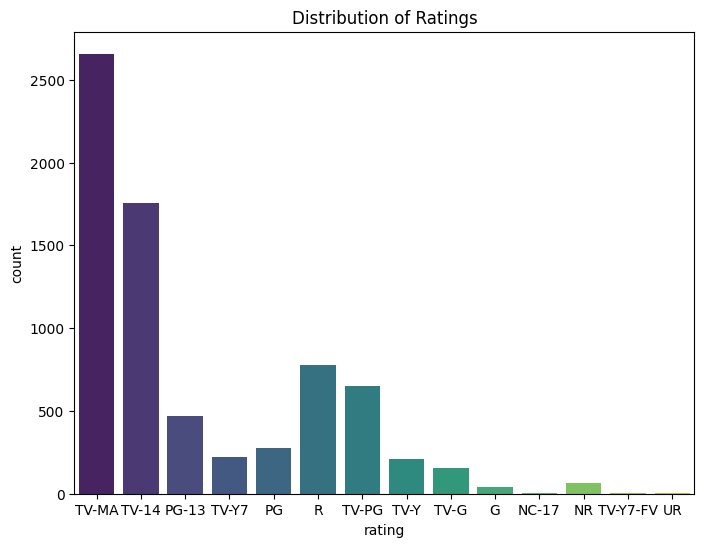

In [98]:
#what is the distribution of rating
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribution of Ratings')


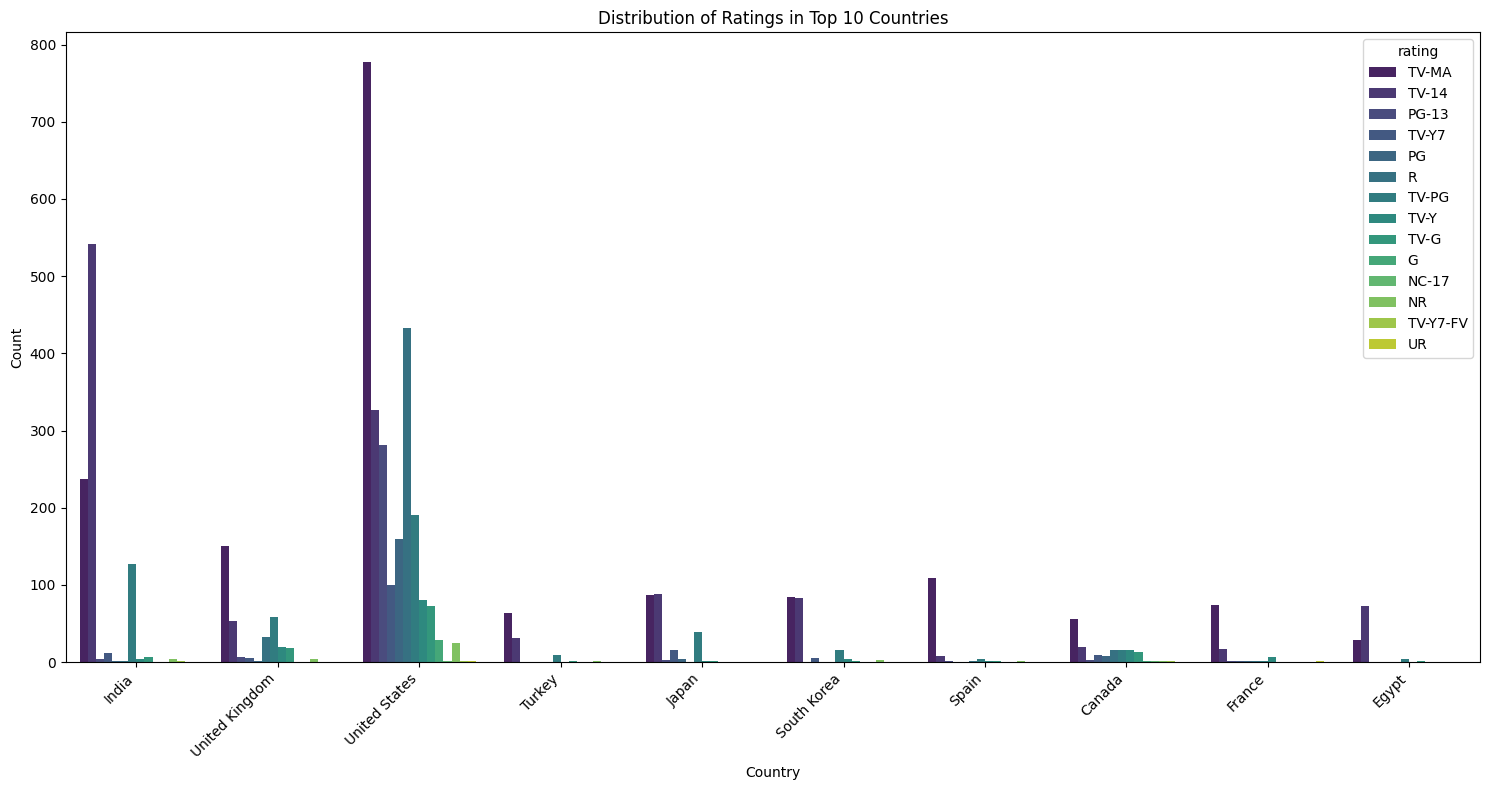

In [99]:
#what is the distribution of rating in each country
plt.figure(figsize=(15, 8))
sns.countplot(data=df_top_countries, x='country', hue='rating', palette='viridis')
plt.title('Distribution of Ratings in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

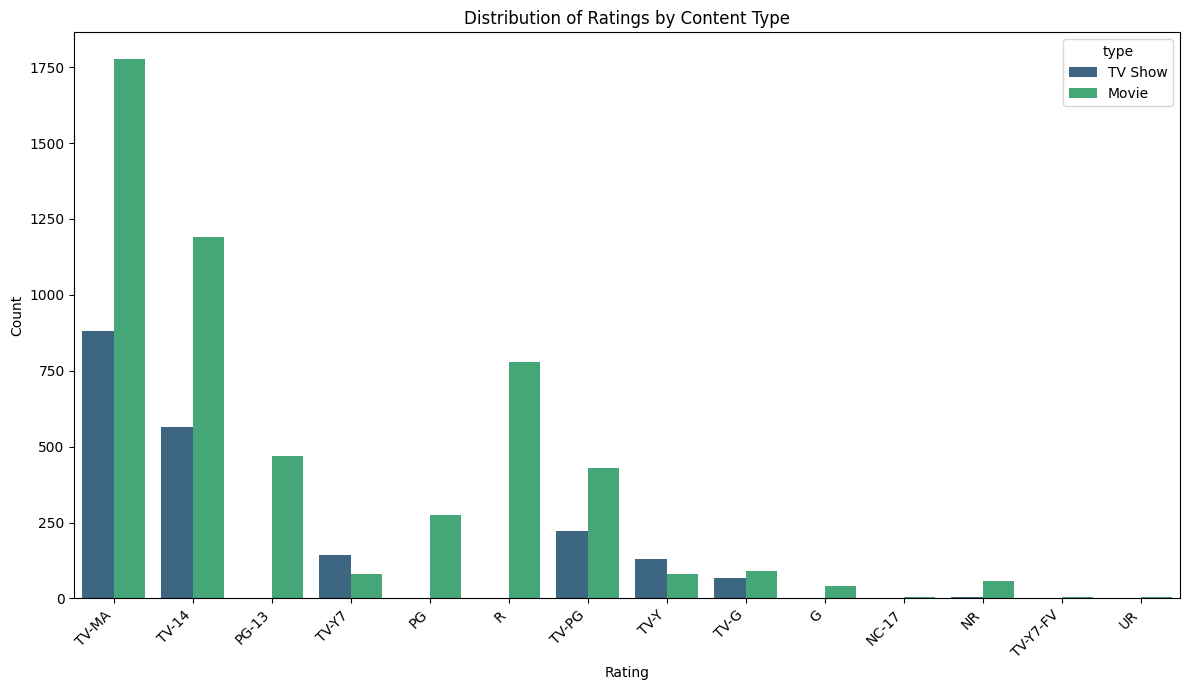

In [102]:
#distibution of rating on types
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='rating', hue='type', palette='viridis')
plt.title('Distribution of Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()